In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split

In [2]:
from sklearn.datasets import fetch_california_housing

housing_data = fetch_california_housing()

X = housing_data.data
y = housing_data.target

feature_names = housing_data.feature_names

print("Input data shape:", X.shape)
print("Target labels shape:", y.shape)

Input data shape: (20640, 8)
Target labels shape: (20640,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=5
)

In [4]:
classifier = ExtraTreesClassifier(
    n_estimators=200,
    random_state=0
)

y_train_class = (y_train > np.median(y_train)).astype(int)

classifier.fit(X_train, y_train_class)

ExtraTreesClassifier(n_estimators=200, random_state=0)

In [5]:
feature_importance = classifier.feature_importances_

for importance, feature_name in zip(feature_importance, feature_names):
    print(feature_name, ":", round(importance, 4))

MedInc : 0.2823
HouseAge : 0.0631
AveRooms : 0.0821
AveBedrms : 0.0551
Population : 0.0541
AveOccup : 0.1148
Latitude : 0.1693
Longitude : 0.1791


In [6]:
sorted_indices = np.argsort(feature_importance)[::-1]

print("Feature importance ranking:")

for index in sorted_indices:
    print(feature_names[index], ":", round(feature_importance[index], 4))

Feature importance ranking:
MedInc : 0.2823
Longitude : 0.1791
Latitude : 0.1693
AveOccup : 0.1148
AveRooms : 0.0821
HouseAge : 0.0631
AveBedrms : 0.0551
Population : 0.0541


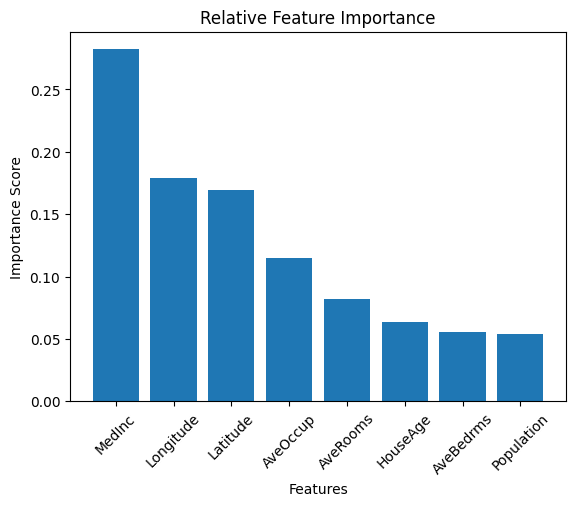

In [7]:
plt.figure()

plt.bar(
    range(len(feature_importance)),
    feature_importance[sorted_indices]
)

plt.xticks(
    range(len(feature_importance)),
    np.array(feature_names)[sorted_indices],
    rotation=45
)

plt.title("Relative Feature Importance")

plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.show()